# Importing libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reading the dataset

In [3]:
data = pd.read_csv('Preprocessed_dataset_knn(5neighbour).csv')
data.head()

,Project County,Project City,Gas Utility,Electric Utility,Total Project Cost,Pre-Retrofit Home Heating Fuel Type,Year Home Built,Size Of Home,Number Of Units,Job Type,...,Estimated Annual kWh Savings,Estimated Annual MMBtu Savings,First Year Modeled Project Energy Savings $ Estimate,size_of_home_flag,Location_1_latitude,Location_1_Longitude,Project Completion Year,Project Completion Month,Project Completion Day,Age of Home
0,Broome,Endicott,New York State Electric & Gas,New York State Electric & Gas,9661.0,Oil,1973,1484,1,Home Performance,...,277.0,24.0,6.826545,0,42.110115,-76.032545,2023,6,22,50
1,Queens,Queens,National Grid,Consolidated Edison,11867.0,Natural Gas,1933,1664,1,Home Performance,...,1062.0,66.0,7.221105,0,40.697715,-73.786045,2023,6,22,90
2,Oswego,Fulton,National Grid,National Grid,9998.0,Natural Gas,1944,1252,1,Home Performance,...,59.0,60.0,6.489205,0,43.325035,-76.411740,2023,6,20,79
3,St. Lawrence,Nicholville,Saint Lawrence Gas,National Grid,6880.0,Oil,1914,1700,1,Home Performance,...,482.0,15.0,6.445720,0,44.695165,-74.704765,2023,6,13,109
4,Oswego,Cleveland,National Grid,National Grid,12289.0,Oil,1891,2680,1,Home Performance,...,690.0,78.0,7.490529,0,43.231255,-75.868192,2023,6,13,132


In [4]:
data.head()

,Project County,Project City,Gas Utility,Electric Utility,Total Project Cost,Pre-Retrofit Home Heating Fuel Type,Year Home Built,Size Of Home,Number Of Units,Job Type,...,Estimated Annual kWh Savings,Estimated Annual MMBtu Savings,First Year Modeled Project Energy Savings $ Estimate,size_of_home_flag,Location_1_latitude,Location_1_Longitude,Project Completion Year,Project Completion Month,Project Completion Day,Age of Home
0,Broome,Endicott,New York State Electric & Gas,New York State Electric & Gas,9661.0,Oil,1973,1484,1,Home Performance,...,277.0,24.0,6.826545,0,42.110115,-76.032545,2023,6,22,50
1,Queens,Queens,National Grid,Consolidated Edison,11867.0,Natural Gas,1933,1664,1,Home Performance,...,1062.0,66.0,7.221105,0,40.697715,-73.786045,2023,6,22,90
2,Oswego,Fulton,National Grid,National Grid,9998.0,Natural Gas,1944,1252,1,Home Performance,...,59.0,60.0,6.489205,0,43.325035,-76.411740,2023,6,20,79
3,St. Lawrence,Nicholville,Saint Lawrence Gas,National Grid,6880.0,Oil,1914,1700,1,Home Performance,...,482.0,15.0,6.445720,0,44.695165,-74.704765,2023,6,13,109
4,Oswego,Cleveland,National Grid,National Grid,12289.0,Oil,1891,2680,1,Home Performance,...,690.0,78.0,7.490529,0,43.231255,-75.868192,2023,6,13,132


# Dataset inspection

In [5]:
data.shape

(51867, 22)

In [6]:
data.dtypes

Project County                                              str
Project City                                                str
Gas Utility                                                 str
Electric Utility                                            str
Total Project Cost                                      float64
Pre-Retrofit Home Heating Fuel Type                         str
Year Home Built                                           int64
Size Of Home                                              int64
Number Of Units                                           int64
Job Type                                                    str
Type Of Dwelling                                            str
Measure Type                                                str
Estimated Annual kWh Savings                            float64
Estimated Annual MMBtu Savings                          float64
First Year Modeled Project Energy Savings $ Estimate    float64
size_of_home_flag                       

In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 51867 entries, 0 to 51866
Data columns (total 22 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   Project County                                        51867 non-null  str    
 1   Project City                                          51867 non-null  str    
 2   Gas Utility                                           51867 non-null  str    
 3   Electric Utility                                      51867 non-null  str    
 4   Total Project Cost                                    51867 non-null  float64
 5   Pre-Retrofit Home Heating Fuel Type                   51867 non-null  str    
 6   Year Home Built                                       51867 non-null  int64  
 7   Size Of Home                                          51867 non-null  int64  
 8   Number Of Units                                       51867 non-nul

In [8]:
data.isnull().sum()

Project County                                          0
Project City                                            0
Gas Utility                                             0
Electric Utility                                        0
Total Project Cost                                      0
Pre-Retrofit Home Heating Fuel Type                     0
Year Home Built                                         0
Size Of Home                                            0
Number Of Units                                         0
Job Type                                                0
Type Of Dwelling                                        0
Measure Type                                            0
Estimated Annual kWh Savings                            0
Estimated Annual MMBtu Savings                          0
First Year Modeled Project Energy Savings $ Estimate    0
size_of_home_flag                                       0
Location_1_latitude                                     0
Location_1_Lon

In [9]:
data[data['First Year Modeled Project Energy Savings $ Estimate'].isna()]

,Project County,Project City,Gas Utility,Electric Utility,Total Project Cost,Pre-Retrofit Home Heating Fuel Type,Year Home Built,Size Of Home,Number Of Units,Job Type,...,Estimated Annual kWh Savings,Estimated Annual MMBtu Savings,First Year Modeled Project Energy Savings $ Estimate,size_of_home_flag,Location_1_latitude,Location_1_Longitude,Project Completion Year,Project Completion Month,Project Completion Day,Age of Home


# Dropping null values as the number of null values is less than 1%

In [10]:
data = data.dropna()

In [11]:
data.isnull().sum()

Project County                                          0
Project City                                            0
Gas Utility                                             0
Electric Utility                                        0
Total Project Cost                                      0
Pre-Retrofit Home Heating Fuel Type                     0
Year Home Built                                         0
Size Of Home                                            0
Number Of Units                                         0
Job Type                                                0
Type Of Dwelling                                        0
Measure Type                                            0
Estimated Annual kWh Savings                            0
Estimated Annual MMBtu Savings                          0
First Year Modeled Project Energy Savings $ Estimate    0
size_of_home_flag                                       0
Location_1_latitude                                     0
Location_1_Lon

# Building new feature columns and dropping the existing once to solve for multicolinearity

In [12]:
data.columns

Index(['Project County', 'Project City', 'Gas Utility', 'Electric Utility',
       'Total Project Cost', 'Pre-Retrofit Home Heating Fuel Type',
       'Year Home Built', 'Size Of Home', 'Number Of Units', 'Job Type',
       'Type Of Dwelling', 'Measure Type', 'Estimated Annual kWh Savings',
       'Estimated Annual MMBtu Savings',
       'First Year Modeled Project Energy Savings $ Estimate',
       'size_of_home_flag', 'Location_1_latitude', 'Location_1_Longitude',
       'Project Completion Year', 'Project Completion Month',
       'Project Completion Day', 'Age of Home'],
      dtype='str')

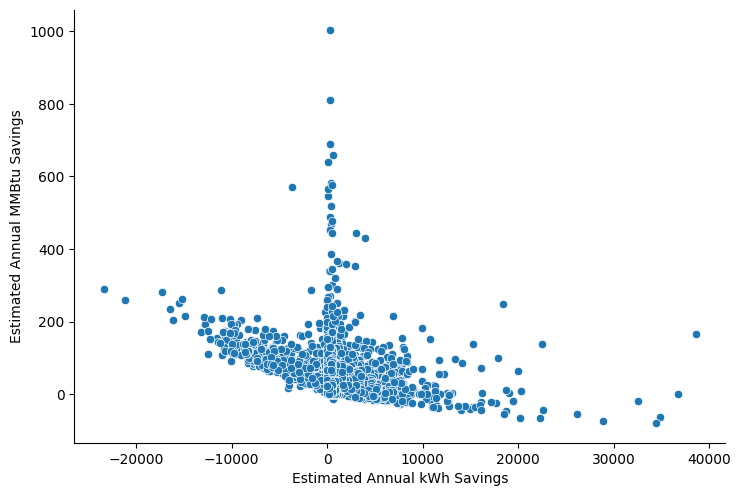

In [13]:
x = data['Estimated Annual kWh Savings']
y = data['Estimated Annual MMBtu Savings']
sns.pairplot(data, x_vars=['Estimated Annual kWh Savings'], y_vars=['Estimated Annual MMBtu Savings'], height=5, aspect=1.5)

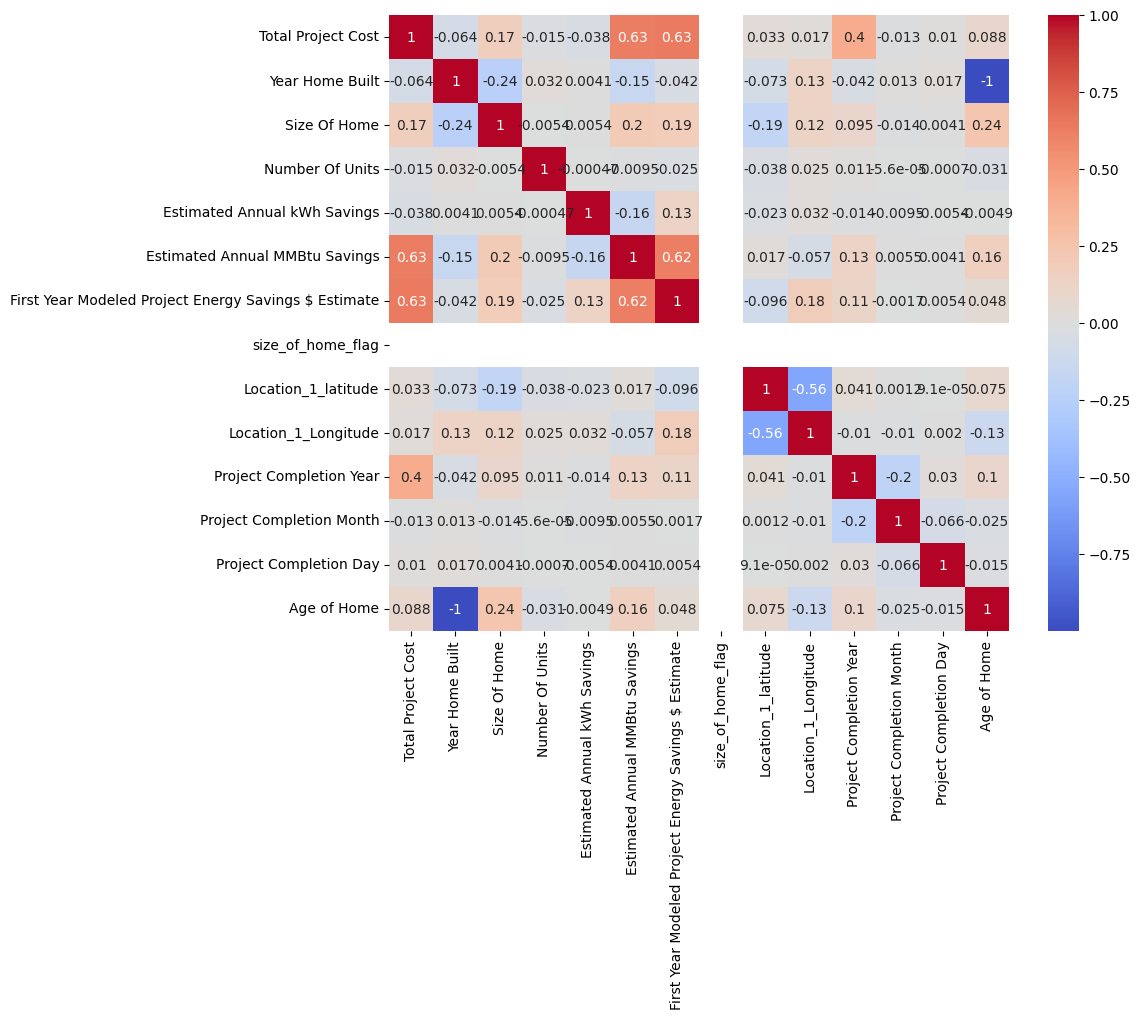

In [14]:
num_col = data.select_dtypes(include=['int64', 'float64']).columns
corr = data[num_col].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

## Findings 
1. Project zip is not a numerical column, its a categorical data since its location has different zip code, therefore this correlation is artificial created 
   a. Either remove zipcode
   b. Encode the project zipcode 
2. Total Project Cost has strong positive correlation with:
        Estimated Annual MMBtu Savings (+0.63)
        First-Year Energy Savings ($) (+0.63)
    This suggests that higher investments lead to higher energy and monetary savings.
3. Estimated MMBtu Savings and Project Cost are strongly correlated with the target variable (~0.62–0.63), indicating possible redundancy or leakage. These features should be carefully evaluated before modeling.

# Age of house

In [15]:
data['Year Home Built'].value_counts()

Year Home Built
1921    2018
1941    1660
1951    1261
1961    1218
1971    1039
        ... 
1813       1
1812       1
1818       1
1817       1
1819       1
Name: count, Length: 216, dtype: int64

In [16]:
data['Project Completion Year'].value_counts()

Project Completion Year
2022    10050
2019     9367
2021     8789
2018     8565
2023     8316
2020     6780
Name: count, dtype: int64

## Findings
since the year built gives us when the house was built which is static datapoint, we need to understand that how old the building was when it was retrofitted to understand the nature of the house because the energy efficiency depends on the age of building rather than the when it was built.
<br>
Assumption:
1. older homes -> poor insulation -> High savings potential post retrofit
2. newer homes -> well insulated -> low savings potential post retrofit

In [17]:
data['Age of Home'] = data['Project Completion Year'] - data['Year Home Built']
data['Age of Home'].describe()

count    51867.000000
mean        72.443326
std         29.468805
min          0.000000
25%         54.000000
50%         73.000000
75%         90.000000
max        233.000000
Name: Age of Home, dtype: float64

# Normalisation of data points

## Project cost

In [18]:
data['Total Project Cost'].describe()

count    51867.000000
mean      6435.772476
std       4154.958606
min        129.000000
25%       3746.000000
50%       5929.000000
75%       8466.000000
max      92297.000000
Name: Total Project Cost, dtype: float64

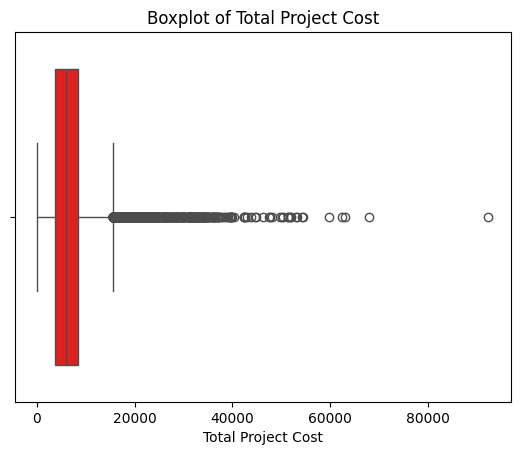

In [19]:
sns.boxplot(x=data['Total Project Cost'], color='red')
plt.title('Boxplot of Total Project Cost')
plt.show()

### Finding

Using summary statistics and boxplot visualization, there is a significant gap between the 75th percentile and the maximum value, indicating the presence of extreme high value observations. This suggests that the distribution is right skewed, where a small number of large project costs extend the upper tail.

Such skewness can adversely affect linear models, as they are sensitive to extreme values, potentially leading to biased coefficient estimates and reduced predictive performance.

In [20]:
data['Cost_per_Sqft'] = data['Total Project Cost'] / data['Size Of Home']
data['Cost_per_Sqft'].describe()


count    51867.000000
mean         4.485980
std          3.108841
min          0.089583
25%          2.302809
50%          3.963024
75%          6.038481
max         44.664000
Name: Cost_per_Sqft, dtype: float64

In [21]:
data['Size Of Home'].value_counts()

Size Of Home
800     2545
924      717
980      686
1200     514
4000     507
        ... 
3953       1
2905       1
3468       1
2849       1
3599       1
Name: count, Length: 2653, dtype: int64

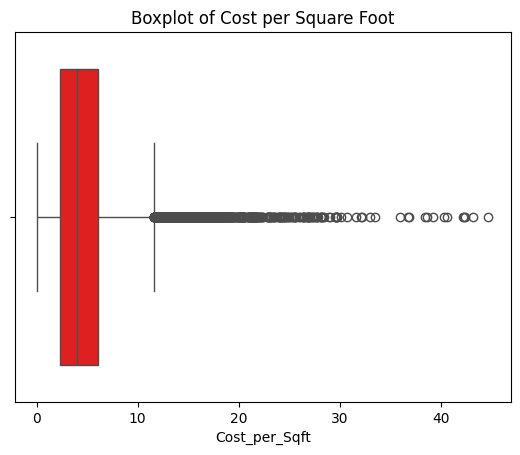

In [22]:
sns.boxplot(x=data['Cost_per_Sqft'], color='red')
plt.title('Boxplot of Cost per Square Foot')
plt.show()

In [23]:
data['log_cost_per_Sqft'] = np.log(data['Cost_per_Sqft'] + 1)  # Adding 1 to avoid log(0)
data['log_cost_per_Sqft'].describe()

count    51867.000000
mean         1.553283
std          0.558052
min          0.085795
25%          1.194773
50%          1.602015
75%          1.951392
max          3.821310
Name: log_cost_per_Sqft, dtype: float64

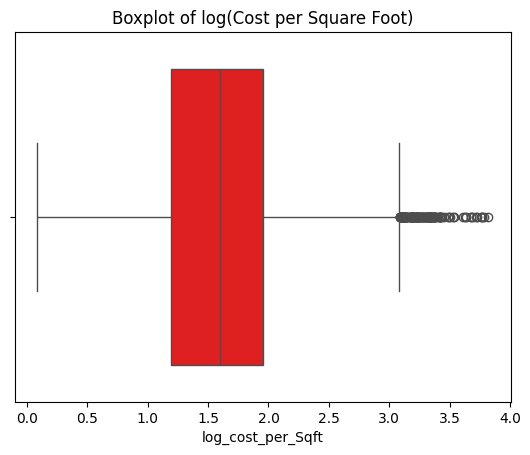

In [24]:
sns.boxplot(x=data['log_cost_per_Sqft'], color='red')
plt.title('Boxplot of log(Cost per Square Foot)')
plt.show()

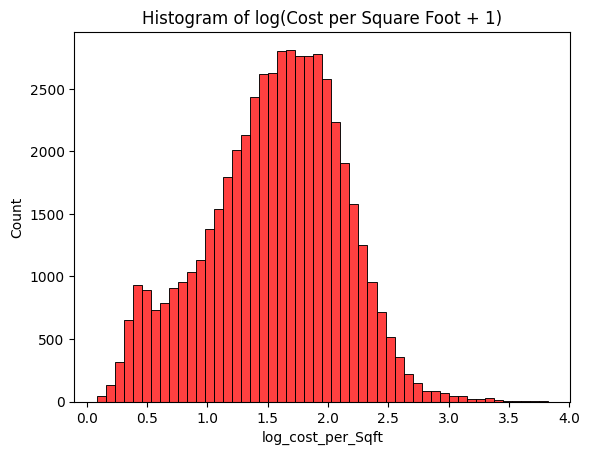

In [25]:
sns.histplot(x=data['log_cost_per_Sqft'], color='red', bins=50)
plt.title('Histogram of log(Cost per Square Foot + 1)')
plt.show()

In [26]:
data.rename(columns={'First Year Modeled Project Energy Savings $ Estimate': 'Log_Annual_Savings_Estimate_in_$'}, inplace=True)
data.drop(columns="Cost_per_Sqft", inplace=True)

## Estimated Annual kWh Savings

In [27]:
data['Estimated Annual kWh Savings'].describe()

count    51867.000000
mean       470.110186
std       1095.896135
min     -23368.000000
25%        158.000000
50%        443.000000
75%        536.000000
max      38572.000000
Name: Estimated Annual kWh Savings, dtype: float64

### Findings

The presence of negative values in Estimated Annual kWh Savings indicates that, for some projects, the modeled post retrofit energy consumption is higher than pre retrofit levels. these projects are estimated to increase energy usage rather than reduce it.

Assumptions:
1. Higher energy usage post retrofit 
2. System change in heating type like gas -> electric or other type of heating

  *The Estimated Annual kWh Savings variable contains negative values, indicating that certain retrofit projects are associated with increased electricity consumption. This may arise due to behavioral changes, fuel switching, or modeling uncertainty. These values are retained as they provide meaningful insights into project performance rather than representing data errors.*

<Axes: xlabel='Estimated Annual kWh Savings', ylabel='Count'>

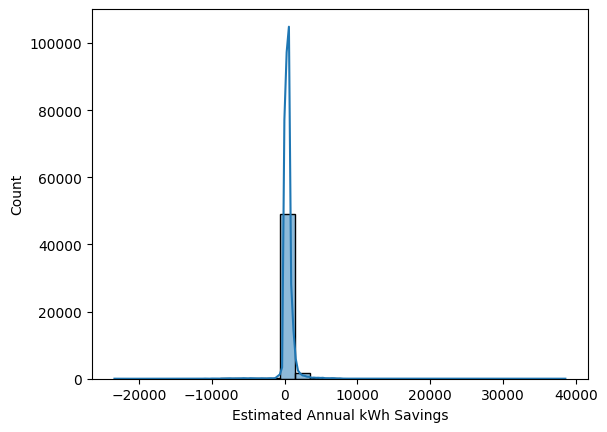

In [28]:
sns.histplot(data['Estimated Annual kWh Savings'], bins=30, kde=True)

In [29]:
data['kWh_savings_per_Sqft'] = data['Estimated Annual kWh Savings'] / data['Size Of Home']

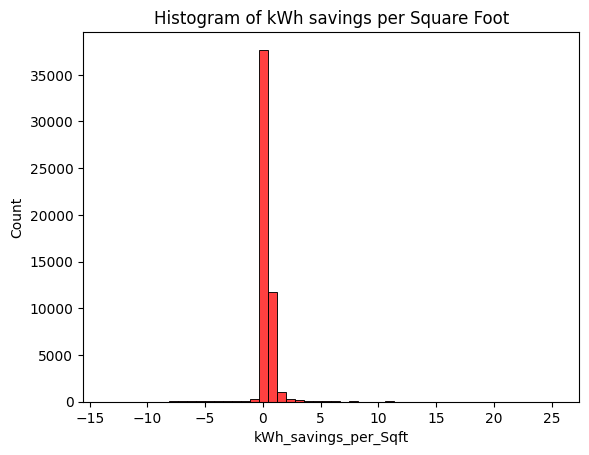

In [30]:
sns.histplot(x=data['kWh_savings_per_Sqft'], color='red', bins=50)
plt.title('Histogram of kWh savings per Square Foot')
plt.show()

## Estimate annual MMBtu savings per sqft

In [31]:
data['Estimated Annual MMBtu Savings'].describe()

count    51867.000000
mean        31.401238
std         27.033473
min        -80.000000
25%         14.000000
50%         26.000000
75%         43.000000
max       1005.000000
Name: Estimated Annual MMBtu Savings, dtype: float64

### Findings 

The MMBtu savings per square foot variable contains both positive and negative values, indicating variability in retrofit effectiveness. Due to the presence of negative values and extreme outliers, log transformation was not appropriate. Instead, the feature was retained in its original scale with outlier capping applied to stabilize the distribution.

In [32]:
data['MMBtu_savings_per_Sqft'] = data['Estimated Annual MMBtu Savings'] / data['Size Of Home']

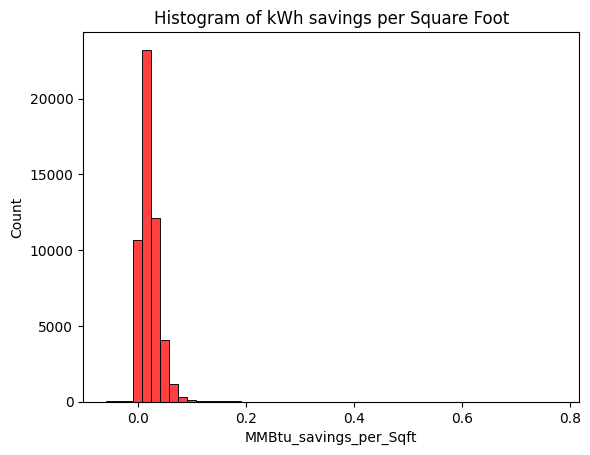

In [33]:
sns.histplot(x=data['MMBtu_savings_per_Sqft'], color='red', bins=50)
plt.title('Histogram of kWh savings per Square Foot')
plt.show()

## Converting the MMBtu savings to kWh savings and merging with electric savings to get a new field called Total_energy_savings

In [34]:
data['total_energy_savings_kwh'] = (
    data['Estimated Annual kWh Savings'] +
    data['Estimated Annual MMBtu Savings'] * 293.071
)

In [35]:
data['total_energy_savings_kwh'].describe()

count     51867.000000
mean       9672.902343
std        7820.263511
min       -3239.923000
25%        4612.994000
50%        8261.846000
75%       13045.053000
max      294805.355000
Name: total_energy_savings_kwh, dtype: float64

In [36]:
data['total_energy_savings_kwh_sqft'] = data['total_energy_savings_kwh'] / data['Size Of Home']
data['total_energy_savings_kwh_sqft'].describe()

count    51867.000000
mean         6.595226
std          5.332354
min         -2.225222
25%          3.032571
50%          5.621704
75%          9.024491
max        227.473268
Name: total_energy_savings_kwh_sqft, dtype: float64

In [37]:
q1 = data['total_energy_savings_kwh_sqft'].quantile(0.01)
q99 = data['total_energy_savings_kwh_sqft'].quantile(0.99)

data['total_energy_savings_kwh_sqft'] = data['total_energy_savings_kwh_sqft'].clip(q1, q99)

In [38]:
data['total_energy_savings_kwh'].describe()

count     51867.000000
mean       9672.902343
std        7820.263511
min       -3239.923000
25%        4612.994000
50%        8261.846000
75%       13045.053000
max      294805.355000
Name: total_energy_savings_kwh, dtype: float64

### Tasks performed 

A combined energy savings feature was constructed by converting MMBtu savings into kWh equivalents. This aggregated measure was further normalized by home size to derive energy savings per square foot, capturing efficiency across properties of varying sizes. Outlier treatment was applied to stabilize the distribution and improve model robustness.

In [39]:
data.columns

Index(['Project County', 'Project City', 'Gas Utility', 'Electric Utility',
       'Total Project Cost', 'Pre-Retrofit Home Heating Fuel Type',
       'Year Home Built', 'Size Of Home', 'Number Of Units', 'Job Type',
       'Type Of Dwelling', 'Measure Type', 'Estimated Annual kWh Savings',
       'Estimated Annual MMBtu Savings', 'Log_Annual_Savings_Estimate_in_$',
       'size_of_home_flag', 'Location_1_latitude', 'Location_1_Longitude',
       'Project Completion Year', 'Project Completion Month',
       'Project Completion Day', 'Age of Home', 'log_cost_per_Sqft',
       'kWh_savings_per_Sqft', 'MMBtu_savings_per_Sqft',
       'total_energy_savings_kwh', 'total_energy_savings_kwh_sqft'],
      dtype='str')

In [40]:
data.drop(columns=['Estimated Annual kWh Savings', 'Estimated Annual MMBtu Savings','total_energy_savings_kwh'], inplace=True)

# Heatmap post feature extraction

In [41]:
data.columns

Index(['Project County', 'Project City', 'Gas Utility', 'Electric Utility',
       'Total Project Cost', 'Pre-Retrofit Home Heating Fuel Type',
       'Year Home Built', 'Size Of Home', 'Number Of Units', 'Job Type',
       'Type Of Dwelling', 'Measure Type', 'Log_Annual_Savings_Estimate_in_$',
       'size_of_home_flag', 'Location_1_latitude', 'Location_1_Longitude',
       'Project Completion Year', 'Project Completion Month',
       'Project Completion Day', 'Age of Home', 'log_cost_per_Sqft',
       'kWh_savings_per_Sqft', 'MMBtu_savings_per_Sqft',
       'total_energy_savings_kwh_sqft'],
      dtype='str')

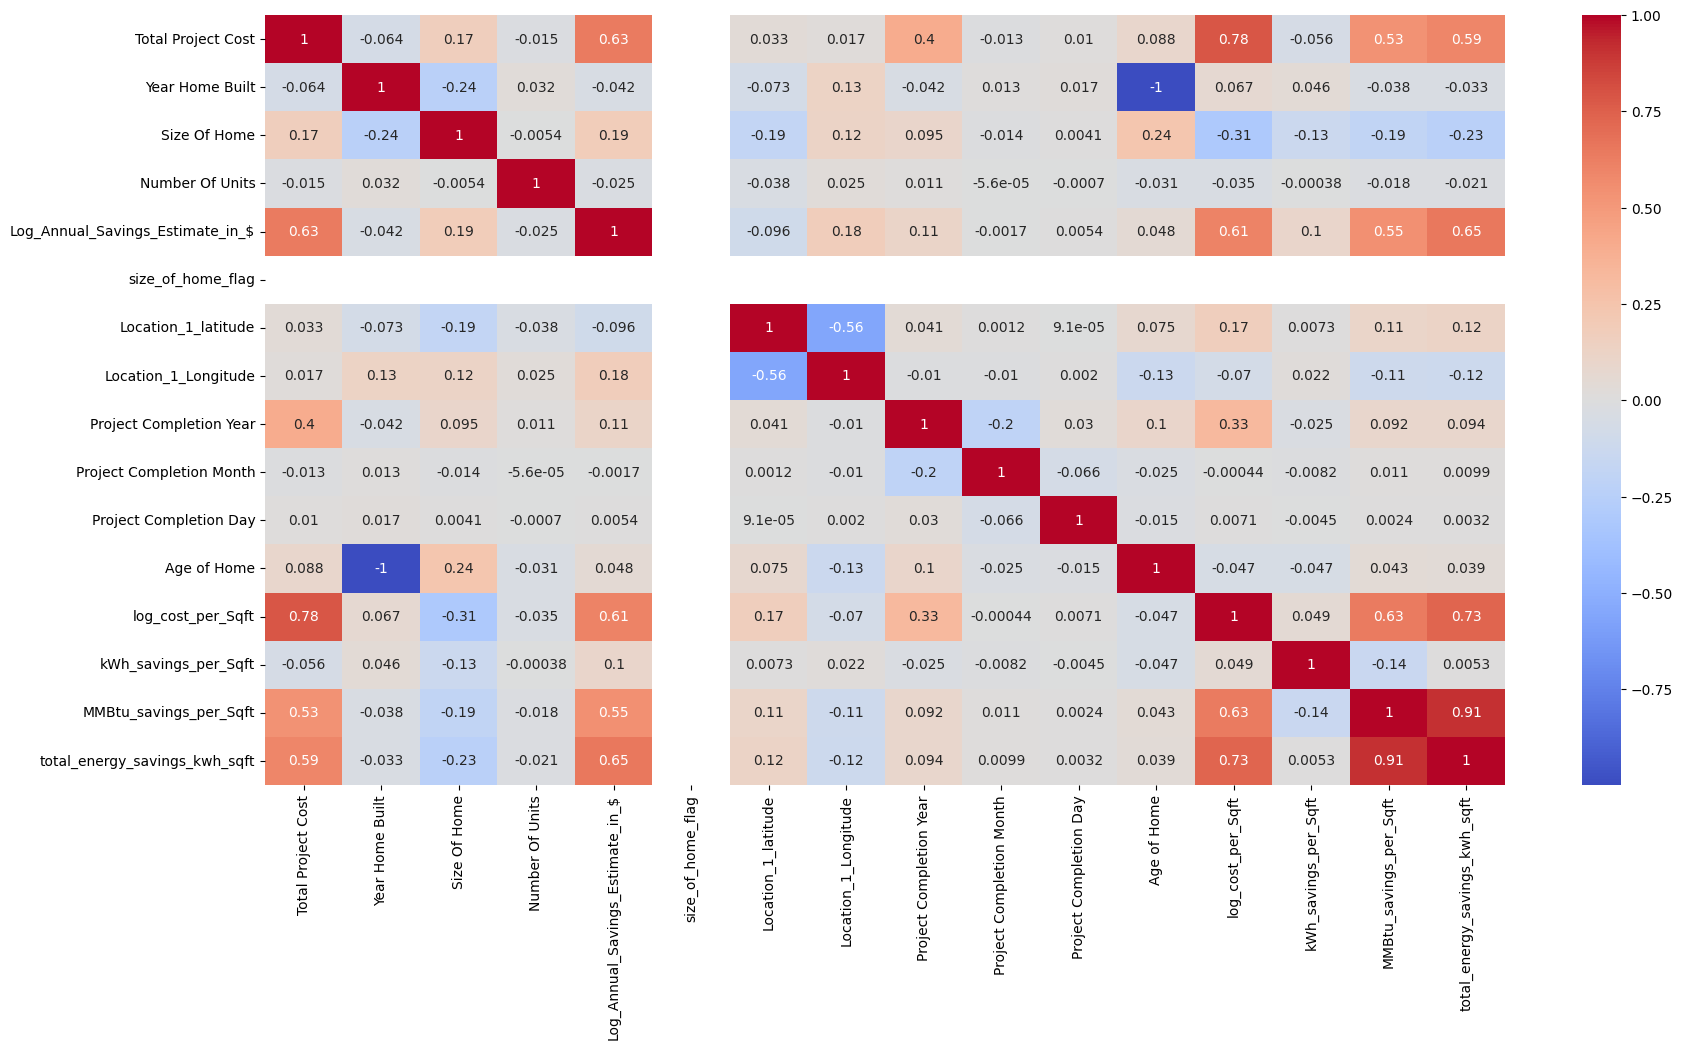

In [42]:
numric_cols = data.select_dtypes(include=['int64', 'float64']).columns
corr = data[numric_cols].corr()
plt.figure(figsize=(20, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

## Findings

1. Delete columns Year Home Built as we have built new derived column Age of Home
2. total_energy_savings_kwh_sqft → 0.65, log_cost_per_Sqft → 0.61, MMBtu_savings_per_Sqft → 0.55, Total Project Cost → 0.63
3. since total energy saving as a strong correlation with MMBtu_savings_per_sqft -> total_energy_savings_kwh_sqft -> 0.91, we can delete either one of the columns, so if we delete MMBtu_savings_per_sqft we need to also delete kWh_savings_per_sqft as the tottal_energy_savings_kwh_sqft contain both these values

*Highly correlated features were removed to avoid multicollinearity. Energy savings variables were consolidated into a single normalized feature (total energy savings per square foot), which showed the strongest relationship with the target. Redundant features such as raw cost and individual energy components were excluded to improve model stability and interpretability.*

# Dropping columns to handle multicolinearity

In [43]:
data.drop(columns=["Year Home Built","MMBtu_savings_per_Sqft","kWh_savings_per_Sqft"], inplace=True)

In [44]:
data.columns

Index(['Project County', 'Project City', 'Gas Utility', 'Electric Utility',
       'Total Project Cost', 'Pre-Retrofit Home Heating Fuel Type',
       'Size Of Home', 'Number Of Units', 'Job Type', 'Type Of Dwelling',
       'Measure Type', 'Log_Annual_Savings_Estimate_in_$', 'size_of_home_flag',
       'Location_1_latitude', 'Location_1_Longitude',
       'Project Completion Year', 'Project Completion Month',
       'Project Completion Day', 'Age of Home', 'log_cost_per_Sqft',
       'total_energy_savings_kwh_sqft'],
      dtype='str')

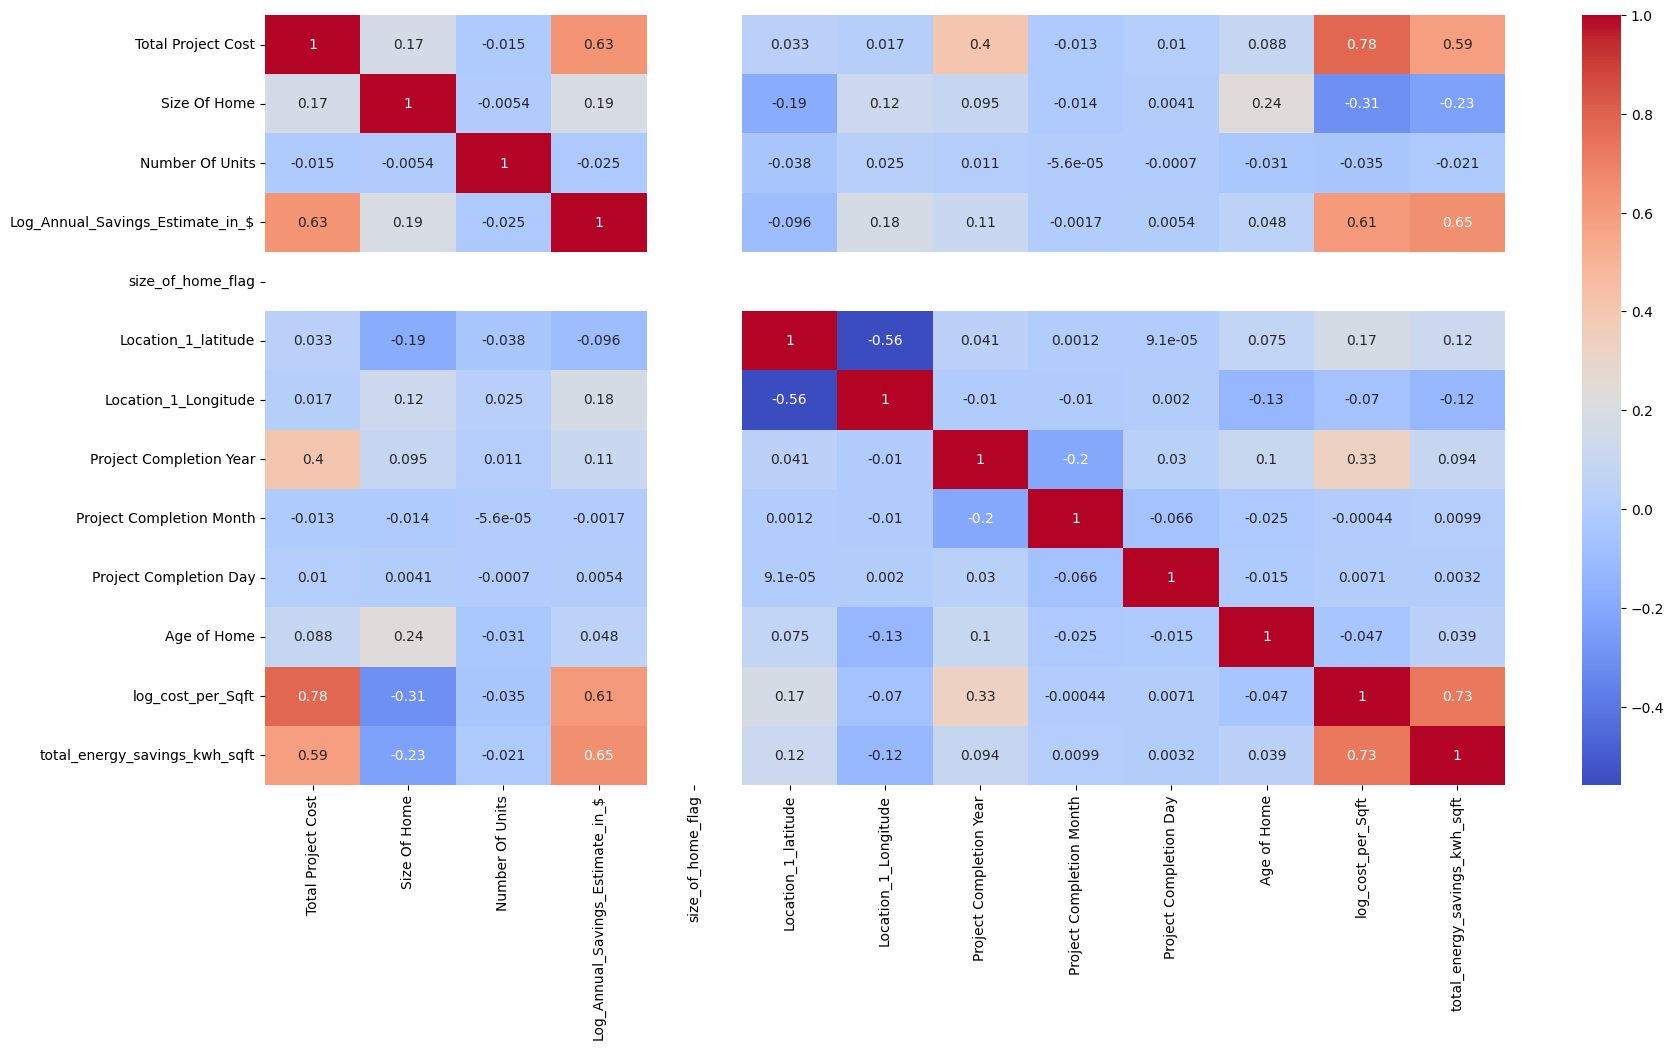

In [45]:
num_col = data.select_dtypes(include=['int64', 'float64']).columns
corr = data[num_col].corr()
plt.figure(figsize=(20, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

# Univariate Analysis

In [46]:
def hist_plot(column):
    sns.histplot(x=data[column], color='red', bins=50)
    plt.title(f'Histogram of {column}')
    plt.show()

In [47]:
def pie_plot(column):
    information = data[column].value_counts()
    plt.figure(figsize=(10, 10))
    plt.pie(information, labels=information.index, autopct='%1.1f%%', startangle=140)
    plt.title(f'Pie Chart of {column}')
    plt.show()

In [48]:
data.columns

Index(['Project County', 'Project City', 'Gas Utility', 'Electric Utility',
       'Total Project Cost', 'Pre-Retrofit Home Heating Fuel Type',
       'Size Of Home', 'Number Of Units', 'Job Type', 'Type Of Dwelling',
       'Measure Type', 'Log_Annual_Savings_Estimate_in_$', 'size_of_home_flag',
       'Location_1_latitude', 'Location_1_Longitude',
       'Project Completion Year', 'Project Completion Month',
       'Project Completion Day', 'Age of Home', 'log_cost_per_Sqft',
       'total_energy_savings_kwh_sqft'],
      dtype='str')

C:\Users\harsh\AppData\Local\Temp\ipykernel_25328\2004629078.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_col = data.select_dtypes(include=['object']).columns


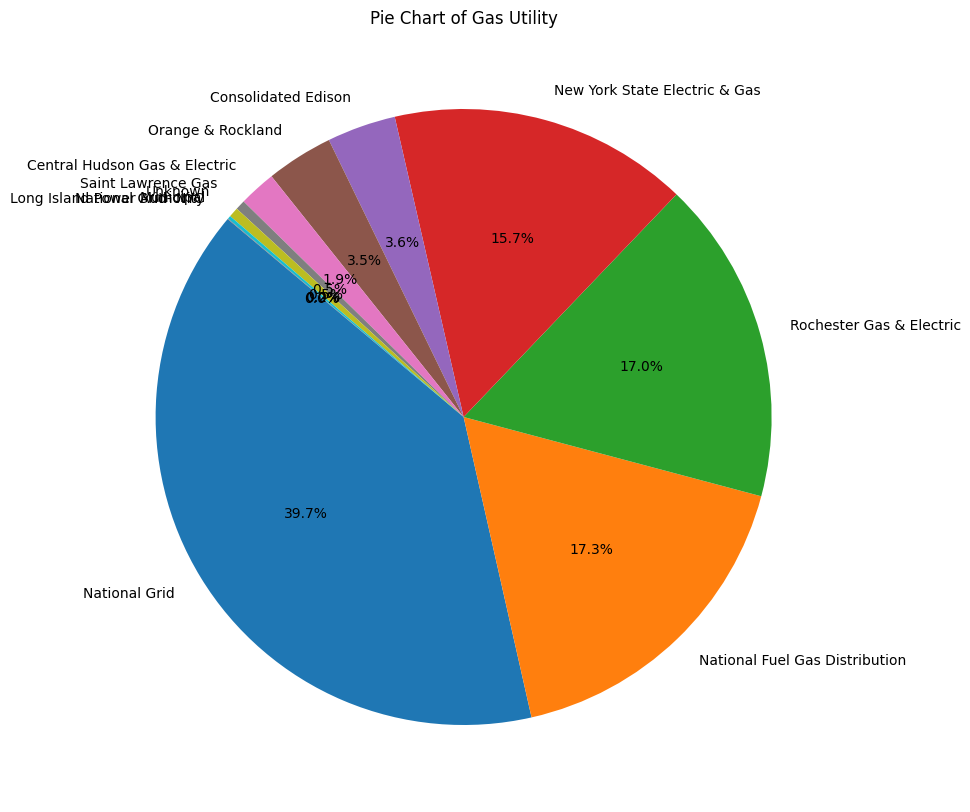

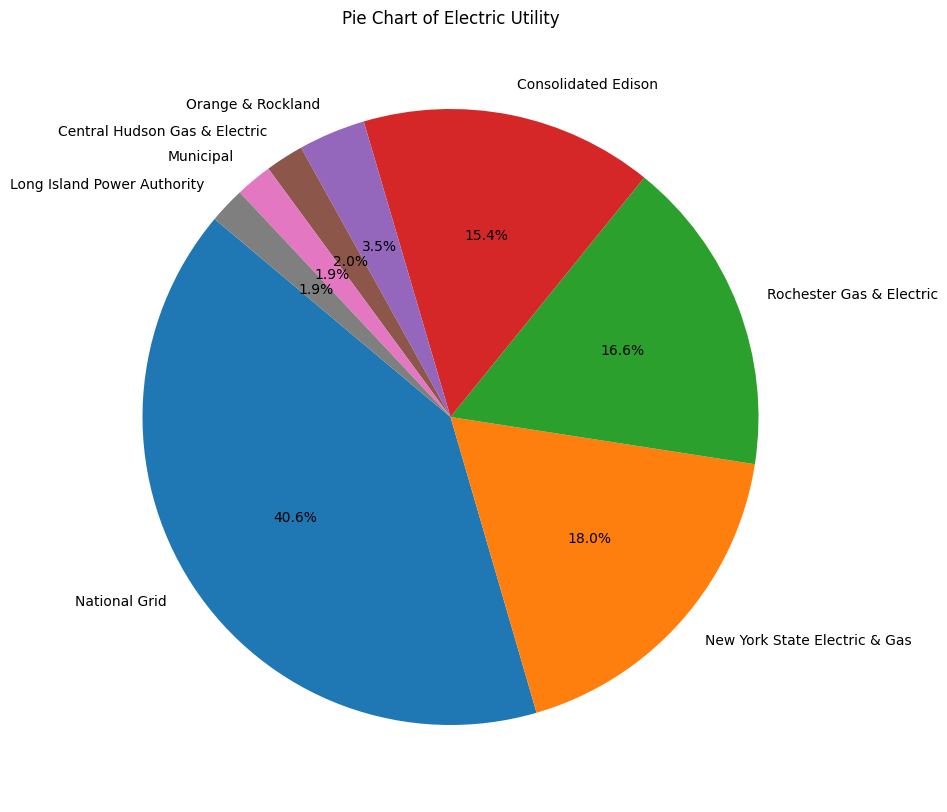

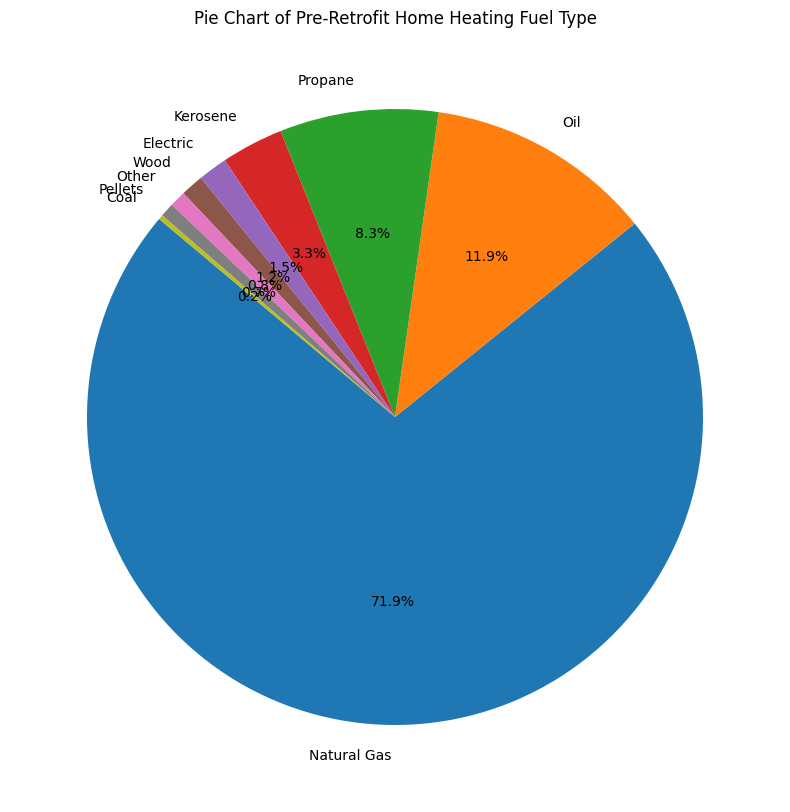

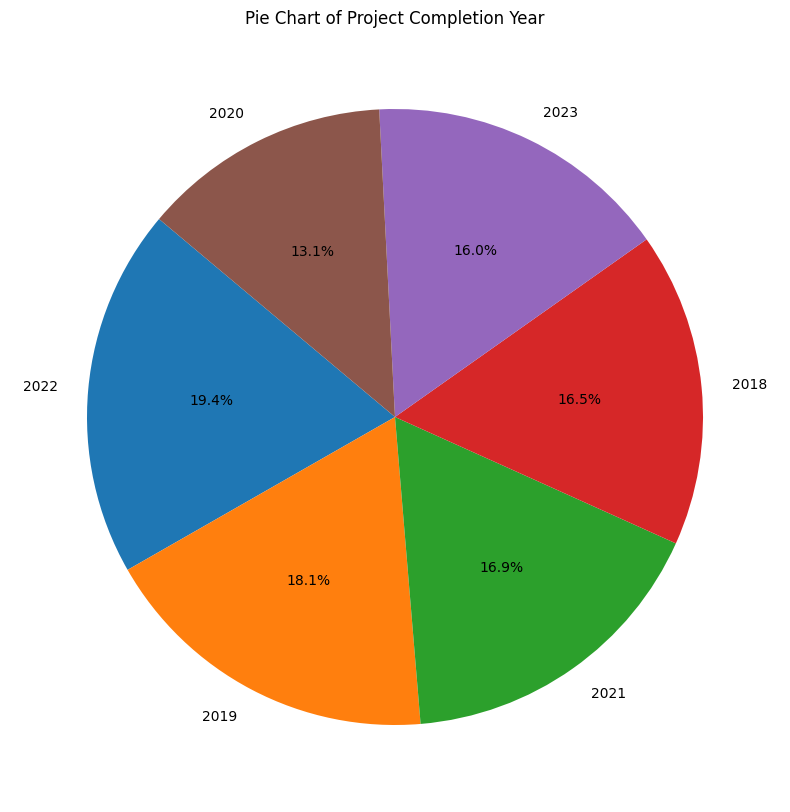

In [49]:
cat_col = data.select_dtypes(include=['object']).columns
pie_plot('Gas Utility')
pie_plot('Electric Utility')
pie_plot('Pre-Retrofit Home Heating Fuel Type')
pie_plot('Project Completion Year')

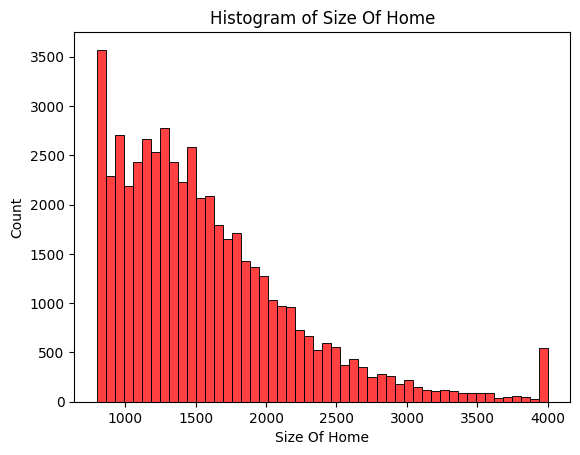

In [50]:
data['Size Of Home'].value_counts()
hist_plot('Size Of Home')

# Bivariate 

# IMP

*Need to Do*

# Multivaraite

# Target Variable

In [51]:
data['Log_Annual_Savings_Estimate_in_$'].describe()

count    51867.000000
mean         5.854329
std          0.875218
min          0.000000
25%          5.356586
50%          5.958425
75%          6.444131
max         10.199547
Name: Log_Annual_Savings_Estimate_in_$, dtype: float64

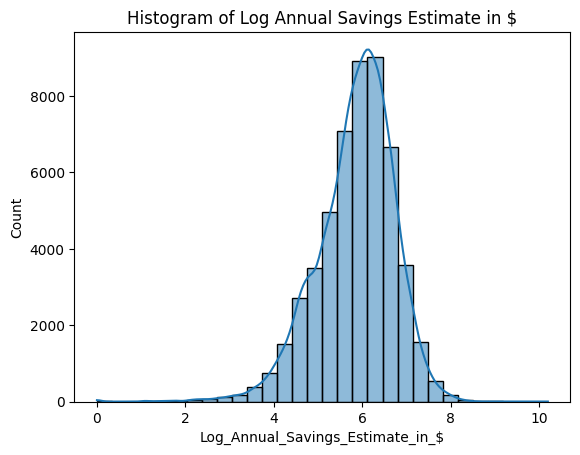

In [52]:
sns.histplot(data['Log_Annual_Savings_Estimate_in_$'], bins=30, kde=True)
plt.title('Histogram of Log Annual Savings Estimate in $')
plt.show()

# Splitting the data into target variable(y) and independent variable(x)

In [53]:
y = data['Log_Annual_Savings_Estimate_in_$']
X = data.drop(columns=['Log_Annual_Savings_Estimate_in_$'])

In [54]:
y

0        6.826545
1        7.221105
2        6.489205
3        6.445720
4        7.490529
           ...   
51862    5.638355
51863    5.768321
51864    5.111988
51865    5.713733
51866    7.504942
Name: Log_Annual_Savings_Estimate_in_$, Length: 51867, dtype: float64

In [55]:
X.columns

Index(['Project County', 'Project City', 'Gas Utility', 'Electric Utility',
       'Total Project Cost', 'Pre-Retrofit Home Heating Fuel Type',
       'Size Of Home', 'Number Of Units', 'Job Type', 'Type Of Dwelling',
       'Measure Type', 'size_of_home_flag', 'Location_1_latitude',
       'Location_1_Longitude', 'Project Completion Year',
       'Project Completion Month', 'Project Completion Day', 'Age of Home',
       'log_cost_per_Sqft', 'total_energy_savings_kwh_sqft'],
      dtype='str')

In [56]:
X

,Project County,Project City,Gas Utility,Electric Utility,Total Project Cost,Pre-Retrofit Home Heating Fuel Type,Size Of Home,Number Of Units,Job Type,Type Of Dwelling,Measure Type,size_of_home_flag,Location_1_latitude,Location_1_Longitude,Project Completion Year,Project Completion Month,Project Completion Day,Age of Home,log_cost_per_Sqft,total_energy_savings_kwh_sqft
0,Broome,Endicott,New York State Electric & Gas,New York State Electric & Gas,9661.0,Oil,1484,1,Home Performance,Single Family,Building Shell,0,42.110115,-76.032545,2023,6,22,50,2.016250,4.926350
1,Queens,Queens,National Grid,Consolidated Edison,11867.0,Natural Gas,1664,1,Home Performance,Single Family,Building Shell,0,40.697715,-73.786045,2023,6,22,90,2.095759,12.262431
2,Oswego,Fulton,National Grid,National Grid,9998.0,Natural Gas,1252,1,Home Performance,Single Family,Building Shell,0,43.325035,-76.411740,2023,6,20,79,2.195626,14.092061
3,St. Lawrence,Nicholville,Saint Lawrence Gas,National Grid,6880.0,Oil,1700,1,Home Performance,Single Family,Building Shell,0,44.695165,-74.704765,2023,6,13,109,1.618806,2.869450
4,Oswego,Cleveland,National Grid,National Grid,12289.0,Oil,2680,1,Home Performance,Single Family,Building Shell,0,43.231255,-75.868192,2023,6,13,132,1.720165,8.787141
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51862,Rockland,Pomona,Orange & Rockland,Orange & Rockland,7984.0,Natural Gas,3628,1,Home Performance,Single Family,Building Shell,0,41.190952,-74.034430,2019,7,26,67,1.163358,1.938728
51863,Cayuga,Auburn,New York State Electric & Gas,New York State Electric & Gas,4678.0,Natural Gas,1456,1,Home Performance,Single Family,Building Shell,0,42.935500,-76.566870,2018,11,9,97,1.438154,5.583685
51864,Rensselaer,Troy,National Grid,National Grid,2931.0,Natural Gas,1275,1,Home Performance,Single Family,Building Shell,0,42.726280,-73.688825,2018,11,12,97,1.193566,3.801675
51865,Queens,Queens Village,National Grid,Consolidated Edison,5848.0,Natural Gas,1280,1,Home Performance,Single Family,Building Shell,0,40.723510,-73.737980,2019,5,21,91,1.717171,5.037158


# Encoding of categorical variable

In [57]:
cat_col

Index(['Project County', 'Project City', 'Gas Utility', 'Electric Utility',
       'Pre-Retrofit Home Heating Fuel Type', 'Job Type', 'Type Of Dwelling',
       'Measure Type'],
      dtype='str')

In [58]:
cat_col_df = data[cat_col]
cat_col_df.head()

,Project County,Project City,Gas Utility,Electric Utility,Pre-Retrofit Home Heating Fuel Type,Job Type,Type Of Dwelling,Measure Type
0,Broome,Endicott,New York State Electric & Gas,New York State Electric & Gas,Oil,Home Performance,Single Family,Building Shell
1,Queens,Queens,National Grid,Consolidated Edison,Natural Gas,Home Performance,Single Family,Building Shell
2,Oswego,Fulton,National Grid,National Grid,Natural Gas,Home Performance,Single Family,Building Shell
3,St. Lawrence,Nicholville,Saint Lawrence Gas,National Grid,Oil,Home Performance,Single Family,Building Shell
4,Oswego,Cleveland,National Grid,National Grid,Oil,Home Performance,Single Family,Building Shell


## Label Encoding 

In [59]:
from sklearn.preprocessing import OneHotEncoder

In [60]:
data.columns

Index(['Project County', 'Project City', 'Gas Utility', 'Electric Utility',
       'Total Project Cost', 'Pre-Retrofit Home Heating Fuel Type',
       'Size Of Home', 'Number Of Units', 'Job Type', 'Type Of Dwelling',
       'Measure Type', 'Log_Annual_Savings_Estimate_in_$', 'size_of_home_flag',
       'Location_1_latitude', 'Location_1_Longitude',
       'Project Completion Year', 'Project Completion Month',
       'Project Completion Day', 'Age of Home', 'log_cost_per_Sqft',
       'total_energy_savings_kwh_sqft'],
      dtype='str')

In [61]:
cat_col

Index(['Project County', 'Project City', 'Gas Utility', 'Electric Utility',
       'Pre-Retrofit Home Heating Fuel Type', 'Job Type', 'Type Of Dwelling',
       'Measure Type'],
      dtype='str')

In [62]:
data['Electric Utility'].nunique()

8

In [63]:
frequency_data = data[['Project County','Project City']]
OHE_data = data[['Job Type','Type Of Dwelling','Measure Type','Pre-Retrofit Home Heating Fuel Type','Gas Utility','Electric Utility']]

### Frequency Encoding

In [64]:
for i in frequency_data.columns:
    frequency_map = frequency_data[i].value_counts(normalize=True)
    X[i + '_freq'] = data[i].map(frequency_map)

### One Hot Encoding

In [65]:
le = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_array = le.fit_transform(X[OHE_data.columns])

# 3. Create a new DataFrame with the new OHE column names
encoded_cols = pd.DataFrame(
    encoded_array,
    columns=le.get_feature_names_out(OHE_data.columns),
    index=X.index
)

# 4. Drop the original text columns and join the new 0/1 columns
X = pd.concat([X.drop(columns=OHE_data.columns), encoded_cols], axis=1)

X.head()

,Project County,Project City,Total Project Cost,Size Of Home,Number Of Units,size_of_home_flag,Location_1_latitude,Location_1_Longitude,Project Completion Year,Project Completion Month,...,Gas Utility_Saint Lawrence Gas,Gas Utility_Unknown,Electric Utility_Central Hudson Gas & Electric,Electric Utility_Consolidated Edison,Electric Utility_Long Island Power Authority,Electric Utility_Municipal,Electric Utility_National Grid,Electric Utility_New York State Electric & Gas,Electric Utility_Orange & Rockland,Electric Utility_Rochester Gas & Electric
0,Broome,Endicott,9661.0,1484,1,0,42.110115,-76.032545,2023,6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,Queens,Queens,11867.0,1664,1,0,40.697715,-73.786045,2023,6,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Oswego,Fulton,9998.0,1252,1,0,43.325035,-76.411740,2023,6,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,St. Lawrence,Nicholville,6880.0,1700,1,0,44.695165,-74.704765,2023,6,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,Oswego,Cleveland,12289.0,2680,1,0,43.231255,-75.868192,2023,6,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [66]:
X = X.drop(columns=['Project County', 'Project City'])

In [67]:
X.head()

,Total Project Cost,Size Of Home,Number Of Units,size_of_home_flag,Location_1_latitude,Location_1_Longitude,Project Completion Year,Project Completion Month,Project Completion Day,Age of Home,...,Gas Utility_Saint Lawrence Gas,Gas Utility_Unknown,Electric Utility_Central Hudson Gas & Electric,Electric Utility_Consolidated Edison,Electric Utility_Long Island Power Authority,Electric Utility_Municipal,Electric Utility_National Grid,Electric Utility_New York State Electric & Gas,Electric Utility_Orange & Rockland,Electric Utility_Rochester Gas & Electric
0,9661.0,1484,1,0,42.110115,-76.032545,2023,6,22,50,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,11867.0,1664,1,0,40.697715,-73.786045,2023,6,22,90,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,9998.0,1252,1,0,43.325035,-76.411740,2023,6,20,79,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,6880.0,1700,1,0,44.695165,-74.704765,2023,6,13,109,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,12289.0,2680,1,0,43.231255,-75.868192,2023,6,13,132,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [68]:
X.isnull().sum()

Total Project Cost                                 0
Size Of Home                                       0
Number Of Units                                    0
size_of_home_flag                                  0
Location_1_latitude                                0
Location_1_Longitude                               0
Project Completion Year                            0
Project Completion Month                           0
Project Completion Day                             0
Age of Home                                        0
log_cost_per_Sqft                                  0
total_energy_savings_kwh_sqft                      0
Project County_freq                                0
Project City_freq                                  0
Job Type_Electric Reduction                        0
Job Type_Home Performance                          0
Type Of Dwelling_2-4 Family                        0
Type Of Dwelling_Mobile                            0
Type Of Dwelling_Single Family                

# Standard Scalar

In [69]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,Total Project Cost,Size Of Home,Number Of Units,size_of_home_flag,Location_1_latitude,Location_1_Longitude,Project Completion Year,Project Completion Month,Project Completion Day,Age of Home,...,Gas Utility_Saint Lawrence Gas,Gas Utility_Unknown,Electric Utility_Central Hudson Gas & Electric,Electric Utility_Consolidated Edison,Electric Utility_Long Island Power Authority,Electric Utility_Municipal,Electric Utility_National Grid,Electric Utility_New York State Electric & Gas,Electric Utility_Orange & Rockland,Electric Utility_Rochester Gas & Electric
0,0.776243,-0.141343,-0.026711,0.0,-0.390346,0.045745,1.439575,-0.0129,0.715990,-0.761603,...,-0.071798,-0.071798,-0.143184,-0.426258,-0.138919,-0.139996,-0.827039,2.131043,-0.19097,-0.446422
1,1.307180,0.145439,-0.026711,0.0,-1.845611,1.270396,1.439575,-0.0129,0.715990,0.595777,...,-0.071798,-0.071798,-0.143184,2.345996,-0.138919,-0.139996,-0.827039,-0.469254,-0.19097,-0.446422
2,0.857352,-0.510972,-0.026711,0.0,0.861446,-0.160968,1.439575,-0.0129,0.484818,0.222498,...,-0.071798,-0.071798,-0.143184,-0.426258,-0.138919,-0.139996,1.209133,-0.469254,-0.19097,-0.446422
3,0.106916,0.202795,-0.026711,0.0,2.273158,0.769567,1.439575,-0.0129,-0.324287,1.240533,...,13.927983,-0.071798,-0.143184,-0.426258,-0.138919,-0.139996,1.209133,-0.469254,-0.19097,-0.446422
4,1.408747,1.764162,-0.026711,0.0,0.764819,0.135340,1.439575,-0.0129,-0.324287,2.021027,...,-0.071798,-0.071798,-0.143184,-0.426258,-0.138919,-0.139996,1.209133,-0.469254,-0.19097,-0.446422


# Split the data into train and test split

In [70]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [71]:
x_train

,Total Project Cost,Size Of Home,Number Of Units,size_of_home_flag,Location_1_latitude,Location_1_Longitude,Project Completion Year,Project Completion Month,Project Completion Day,Age of Home,...,Gas Utility_Saint Lawrence Gas,Gas Utility_Unknown,Electric Utility_Central Hudson Gas & Electric,Electric Utility_Consolidated Edison,Electric Utility_Long Island Power Authority,Electric Utility_Municipal,Electric Utility_National Grid,Electric Utility_New York State Electric & Gas,Electric Utility_Orange & Rockland,Electric Utility_Rochester Gas & Electric
2290,1.199356,0.285643,-0.026711,0.0,0.624718,0.484583,1.439575,-0.012900,-1.711323,0.324301,...,-0.071798,-0.071798,-0.143184,-0.426258,-0.138919,-0.139996,1.209133,-0.469254,-0.19097,-0.446422
31067,-0.420651,1.636704,-0.026711,0.0,-1.883734,1.199953,-0.306859,0.866693,0.947163,0.527908,...,-0.071798,-0.071798,-0.143184,2.345996,-0.138919,-0.139996,-0.827039,-0.469254,-0.19097,-0.446422
10490,0.671307,1.636704,-0.026711,0.0,0.470114,1.049002,1.439575,-0.306097,0.022472,0.561843,...,-0.071798,-0.071798,-0.143184,-0.426258,-0.138919,-0.139996,1.209133,-0.469254,-0.19097,-0.446422
48414,-0.096217,-1.151452,-0.026711,0.0,-0.438909,0.375481,-1.471148,0.573495,0.831577,-0.490127,...,-0.071798,-0.071798,-0.143184,-0.426258,-0.138919,-0.139996,-0.827039,2.131043,-0.19097,-0.446422
10171,1.193339,-0.096732,-0.026711,0.0,0.586505,-0.818520,0.857431,-0.892492,1.525095,-0.082913,...,-0.071798,-0.071798,-0.143184,-0.426258,-0.138919,-0.139996,-0.827039,-0.469254,-0.19097,2.240034
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,-0.090200,-1.052671,-0.026711,0.0,0.557106,-1.503145,1.439575,-0.892492,-0.786632,0.460039,...,-0.071798,-0.071798,-0.143184,-0.426258,-0.138919,-0.139996,1.209133,-0.469254,-0.19097,-0.446422
44732,1.220777,-0.737211,-0.026711,0.0,-0.344949,-1.627014,-1.471148,1.159890,-0.555459,0.052825,...,-0.071798,-0.071798,-0.143184,-0.426258,-0.138919,-0.139996,1.209133,-0.469254,-0.19097,-0.446422
38158,-1.392512,-0.052122,-0.026711,0.0,0.504390,-0.679430,-0.889003,-0.306097,0.831577,0.460039,...,-0.071798,-0.071798,-0.143184,-0.426258,-0.138919,-0.139996,-0.827039,-0.469254,-0.19097,2.240034
860,1.774578,-0.185953,-0.026711,0.0,-0.424600,1.181503,1.439575,-1.478888,1.062749,0.426105,...,-0.071798,-0.071798,6.984010,-0.426258,-0.138919,-0.139996,-0.827039,-0.469254,-0.19097,-0.446422


In [72]:
y_train

2290     6.643790
31067    6.126869
10490    6.167516
48414    6.712956
10171    6.291569
           ...   
11284    5.298317
44732    7.178545
38158    3.433987
860      6.476972
15795    7.187657
Name: Log_Annual_Savings_Estimate_in_$, Length: 41493, dtype: float64

In [73]:
x_test

,Total Project Cost,Size Of Home,Number Of Units,size_of_home_flag,Location_1_latitude,Location_1_Longitude,Project Completion Year,Project Completion Month,Project Completion Day,Age of Home,...,Gas Utility_Saint Lawrence Gas,Gas Utility_Unknown,Electric Utility_Central Hudson Gas & Electric,Electric Utility_Consolidated Edison,Electric Utility_Long Island Power Authority,Electric Utility_Municipal,Electric Utility_National Grid,Electric Utility_New York State Electric & Gas,Electric Utility_Orange & Rockland,Electric Utility_Rochester Gas & Electric
25886,-1.416580,0.601103,-0.026711,0.0,0.135696,-1.621794,-0.306859,-1.478888,-0.208700,2.156765,...,-0.071798,-0.071798,-0.143184,-0.426258,-0.138919,-0.139996,1.209133,-0.469254,-0.19097,-0.446422
16112,1.618618,-0.976196,-0.026711,0.0,0.581090,0.967090,1.439575,-0.306097,-1.595736,-0.252586,...,-0.071798,-0.071798,-0.143184,-0.426258,-0.138919,-0.139996,1.209133,-0.469254,-0.19097,-0.446422
11667,0.323286,1.904366,0.432641,0.0,-1.871504,1.189227,0.857431,1.746285,0.715990,-0.116848,...,-0.071798,-0.071798,-0.143184,2.345996,-0.138919,-0.139996,-0.827039,-0.469254,-0.19097,-0.446422
42784,-0.965066,-0.232157,-0.026711,0.0,-0.104878,-1.813339,-1.471148,-0.599295,-0.671046,-0.184717,...,-0.071798,-0.071798,-0.143184,-0.426258,-0.138919,7.143043,-0.827039,-0.469254,-0.19097,-0.446422
25850,0.349520,2.281962,-0.026711,0.0,-1.882332,1.298277,-0.889003,0.866693,-1.480150,0.154629,...,-0.071798,-0.071798,-0.143184,2.345996,-0.138919,-0.139996,-0.827039,-0.469254,-0.19097,-0.446422
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17532,-1.420671,-0.969823,-0.026711,0.0,0.425088,-1.404571,0.857431,-1.185690,-0.671046,-0.184717,...,-0.071798,-0.071798,-0.143184,-0.426258,-0.138919,-0.139996,-0.827039,2.131043,-0.19097,-0.446422
42235,-0.765303,-1.219961,-0.026711,0.0,0.714003,-0.814054,-1.471148,-1.478888,0.831577,0.222498,...,-0.071798,-0.071798,-0.143184,-0.426258,-0.138919,-0.139996,-0.827039,-0.469254,-0.19097,2.240034
13312,0.456381,0.433814,-0.026711,0.0,-0.399423,0.113469,0.857431,-1.478888,0.253645,0.188563,...,-0.071798,-0.071798,-0.143184,-0.426258,-0.138919,-0.139996,-0.827039,2.131043,-0.19097,-0.446422
24633,1.092736,-0.087173,-0.026711,0.0,0.056192,-0.999847,-0.889003,1.159890,0.138059,1.036926,...,-0.071798,-0.071798,-0.143184,-0.426258,-0.138919,-0.139996,-0.827039,2.131043,-0.19097,-0.446422


In [74]:
y_test

25886    1.609438
16112    6.536692
11667    6.966967
42784    5.030438
25850    6.642487
           ...   
17532    3.988984
42235    5.384495
13312    5.820083
24633    5.872118
17023    4.700480
Name: Log_Annual_Savings_Estimate_in_$, Length: 10374, dtype: float64

# Linear Regression

In [75]:
from sklearn.linear_model import LinearRegression

linearmodel = LinearRegression()
linearmodel.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [76]:
y_pred = linearmodel.predict(x_test)
y_pred

array([4.34902369, 6.52642557, 6.54443216, ..., 5.63673882, 6.00901558,
       4.87630464], shape=(10374,))

## accuracy Measure

In [77]:
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, mean_absolute_error
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')
print(f'Mean Absolute Error: {mae}')

Mean Squared Error: 0.20231441183933194
R-squared: 0.7385113664650689
Mean Absolute Error: 0.2913944470305094


In [78]:
# Lasso Regression
from sklearn.linear_model import LassoCV

lasso_model = LassoCV(
    alphas=np.logspace(-4, 1, 100),
    cv=5,
    random_state=42,
    max_iter=50000
)

lasso_model.fit(x_train, y_train)
lasso_y_pred = lasso_model.predict(x_test)

# Accuracy measures
mse = mean_squared_error(y_test, lasso_y_pred)
r2 = r2_score(y_test, lasso_y_pred)
mae = mean_absolute_error(y_test, lasso_y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')
print(f'Mean Absolute Error: {mae}')
print(f'Chosen alpha: {lasso_model.alpha_}')

# Non-zero feature summary
lasso_coef = pd.Series(lasso_model.coef_, index=x_train.columns)
selected_features = lasso_coef[lasso_coef != 0].sort_values(key=np.abs, ascending=False)
print(f'Number of selected (non-zero) features: {selected_features.shape[0]}')
selected_features.head(15)

Mean Squared Error: 0.20226135760070355
R-squared: 0.73857993834898
Mean Absolute Error: 0.29129954377893275
Chosen alpha: 0.0001788649529057435
Number of selected (non-zero) features: 44


log_cost_per_Sqft                                  0.464076
total_energy_savings_kwh_sqft                      0.424112
Size Of Home                                       0.406843
Electric Utility_Consolidated Edison               0.165579
Pre-Retrofit Home Heating Fuel Type_Natural Gas   -0.165061
Total Project Cost                                -0.119195
Pre-Retrofit Home Heating Fuel Type_Propane        0.091996
Project Completion Year                           -0.078775
Pre-Retrofit Home Heating Fuel Type_Oil            0.052537
Pre-Retrofit Home Heating Fuel Type_Kerosene       0.040735
Project County_freq                               -0.038719
Type Of Dwelling_Mobile                           -0.031122
Location_1_Longitude                               0.029376
Project City_freq                                  0.028227
Electric Utility_Orange & Rockland                 0.028079
dtype: float64

In [79]:
# Quick diagnostics for model comparison
from sklearn.metrics import r2_score

print('Linear R2:', float(r2_score(y_test, y_pred)))
print('Lasso R2:', float(r2_score(y_test, lasso_y_pred)))
print('Chosen alpha:', float(lasso_model.alpha_))
print('X shape after encoding:', X.shape)
print('Train shape:', x_train.shape, 'Test shape:', x_test.shape)
print('Target name:', y.name)
print('Any NA in X_scaled:', bool(pd.isna(X_scaled).any().any()))
print('Any NA in y:', bool(pd.isna(y).any()))
print('Unique values in y:', int(y.nunique()))

Linear R2: 0.7385113664650689
Lasso R2: 0.73857993834898
Chosen alpha: 0.0001788649529057435
X shape after encoding: (51867, 51)
Train shape: (41493, 51) Test shape: (10374, 51)
Target name: Log_Annual_Savings_Estimate_in_$
Any NA in X_scaled: False
Any NA in y: False
Unique values in y: 2302


# Random Forest

In [78]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train)

RandomForestRegressor(random_state=42)

In [79]:
rf_y_pred = rf_model.predict(x_test)
rf_y_pred

array([3.28919441, 6.24776928, 6.8698606 , ..., 5.65921601, 5.87983834,
       4.60260658])

In [80]:
mse = mean_squared_error(y_test, rf_y_pred)
r2 = r2_score(y_test, rf_y_pred)
mae = mean_absolute_error(y_test, rf_y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')
print(f'Mean Absolute Error: {mae}')

Mean Squared Error: 0.11725454170920531
R-squared: 0.8484500950349799
Mean Absolute Error: 0.1902822352559456


# Hyperparameter Tuning

In [82]:
n_estimators = [50, 100, 200]
max_depth = [None, 10, 20, 30]
min_samples_split = [2, 5, 10]
min_samples_leaf = [1, 2, 4]

In [83]:
from sklearn.model_selection import RandomizedSearchCV
rf_random = RandomizedSearchCV(estimator=rf_model, param_distributions={
    'n_estimators': n_estimators,
    'max_depth': max_depth,
    'min_samples_split': min_samples_split,
    'min_samples_leaf': min_samples_leaf
}, n_iter=10, cv=3, verbose=2, random_state=42, n_jobs=-1)
rf_random.fit(x_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END max_depth=None, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=  25.6s
[CV] END max_depth=None, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=  25.7s
[CV] END max_depth=None, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=  25.7s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=  27.0s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=  27.4s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=  27.0s
[CV] END max_depth=20, min_samples_leaf=4, min_samples_split=5, n_estimators=200; total time=  43.8s
[CV] END max_depth=20, min_samples_leaf=4, min_samples_split=5, n_estimators=200; total time=  44.0s
[CV] END max_depth=20, min_samples_leaf=4, min_samples_split=5, n_estimators=200; total time=  44.0s


KeyboardInterrupt: 

In [ ]:
print(f'Best Parameters: {grid_search.best_params_}')